In [ ]:
from netgen.geom2d import unit_square
from ngsolve import *
import numpy as np
import matplotlib.pyplot as plt
import os


def f_exact(t, S=1.0):
    return S * dtimefac(t) * (x**5 - 10 * x**3 * y**2 + 5 * x * y**4)

def timefac(t):
    return t * t * np.exp(-t * t)


def dtimefac(t):
    return 2.0 * t * (1.0 - t * t) * np.exp(-t * t)


def p_exact(t):
    fac = timefac(t)
    return fac * (x**5 - 10 * x**3 * y**2 + 5 * x * y**4)


def u_exact(t):
    fac = timefac(t)
    return CoefficientFunction((
        -fac * (5 * x**4 - 30 * x * x * y * y + 5 * y**4),
        -fac * (-20 * x**3 * y + 20 * x * y**3)
    ))


def div_u_exact(t):
    return CoefficientFunction(0.0)


def f_exact(t, S=1.0):
    return S * dtimefac(t) * (x**5 - 10 * x**3 * y**2 + 5 * x * y**4)

# Rate helper
def rates_increasing(xvals, evals):
    r = [None]
    for i in range(1, len(evals)):
        r.append(np.log(evals[i - 1] / evals[i]) / np.log(xvals[i] / xvals[i - 1]))
    return r


# Solver
def solve(maxh=0.05, order=1, Sstor=1.0, dt=0.01, T=1.0):
    mesh = Mesh(unit_square.GenerateMesh(maxh=maxh))

    V = HDiv(mesh, order=order)
    Q = L2(mesh, order=order - 1)
    Y = FESpace([V, Q])

    (u, p) = Y.TrialFunction()
    (v, q) = Y.TestFunction()
    n = specialcf.normal(mesh.dim)

    S_cf = CoefficientFunction(Sstor)

    p_old = GridFunction(Q)
    p_old.Set(p_exact(0.0))

    gfu = GridFunction(Y)
    uh, ph = gfu.components

    a = BilinearForm(Y)
    a += (InnerProduct(u, v) - p * div(v) + q * div(u) + (S_cf / dt) * p * q) * dx
    a.Assemble()

    inv = a.mat.Inverse(Y.FreeDofs(), inverse="pardiso")

    Nt = int(round(T / dt))

    # max-in-time absolute errors
    max_err_p = 0.0
    max_err_u = 0.0
    max_err_div = 0.0
    max_err_u_hdiv = 0.0

    # final-time absolute errors
    err_p_T = 0.0
    err_u_T = 0.0
    err_div_T = 0.0
    err_u_hdiv_T = 0.0

    # L2-in-time accumulated squared errors
    l2t_err_p_sq = 0.0
    l2t_err_u_sq = 0.0
    l2t_err_div_sq = 0.0
    l2t_err_u_hdiv_sq = 0.0

    for nstep in range(1, Nt + 1):
        t = nstep * dt

        L = LinearForm(Y)
        L += (f_exact(t, Sstor) * q + (S_cf / dt) * p_old * q) * dx
        L += (-p_exact(t)) * InnerProduct(v.Trace(), n) * ds
        L.Assemble()

        gfu.vec.data = inv * L.vec
        p_old.vec.data = ph.vec

        pT = p_exact(t)
        uT = u_exact(t)
        divuT = div_u_exact(t)

        err_p = sqrt(Integrate((ph - pT) * (ph - pT), mesh))
        err_u = sqrt(Integrate(InnerProduct(uh - uT, uh - uT), mesh))
        err_div = sqrt(Integrate((div(uh) - divuT) * (div(uh) - divuT), mesh))
        err_u_hdiv = np.sqrt(err_u**2 + err_div**2)

        max_err_p = max(max_err_p, err_p)
        max_err_u = max(max_err_u, err_u)
        max_err_div = max(max_err_div, err_div)
        max_err_u_hdiv = max(max_err_u_hdiv, err_u_hdiv)

        err_p_T = err_p
        err_u_T = err_u
        err_div_T = err_div
        err_u_hdiv_T = err_u_hdiv

        l2t_err_p_sq += dt * err_p**2
        l2t_err_u_sq += dt * err_u**2
        l2t_err_div_sq += dt * err_div**2
        l2t_err_u_hdiv_sq += dt * err_u_hdiv**2

    l2t_err_p = np.sqrt(l2t_err_p_sq)
    l2t_err_u = np.sqrt(l2t_err_u_sq)
    l2t_err_div = np.sqrt(l2t_err_div_sq)
    l2t_err_u_hdiv = np.sqrt(l2t_err_u_hdiv_sq)

    return {
        "Np": Q.ndof,
        "Nu": V.ndof,
        "Ntot": Y.ndof,
        "Nt": Nt,

        # max-in-time absolute errors
        "max_err_p": max_err_p,
        "max_err_u": max_err_u,
        "max_err_div": max_err_div,
        "max_err_u_hdiv": max_err_u_hdiv,

        # final-time absolute errors
        "err_p_T": err_p_T,
        "err_u_T": err_u_T,
        "err_div_T": err_div_T,
        "err_u_hdiv_T": err_u_hdiv_T,

        # L2-in-time absolute errors
        "l2t_err_p": l2t_err_p,
        "l2t_err_u": l2t_err_u,
        "l2t_err_div": l2t_err_div,
        "l2t_err_u_hdiv": l2t_err_u_hdiv,
    }


# Convergence data collection
def collect_space_convergence(hs, order=2, dt=1e-4, T=1.0, Sstor=1.0):
    rows = [solve(maxh=h, order=order, dt=dt, T=T, Sstor=Sstor) for h in hs]

    return {
        "h": np.array(hs, dtype=float),
        "Np": np.array([r["Np"] for r in rows], dtype=int),
        "Nu": np.array([r["Nu"] for r in rows], dtype=int),
        "Ntot": np.array([r["Ntot"] for r in rows], dtype=int),

        # max-in-time absolute
        "max_err_p": np.array([r["max_err_p"] for r in rows], dtype=float),
        "max_err_u": np.array([r["max_err_u"] for r in rows], dtype=float),
        "max_err_div": np.array([r["max_err_div"] for r in rows], dtype=float),
        "max_err_u_hdiv": np.array([r["max_err_u_hdiv"] for r in rows], dtype=float),

        # final-time absolute
        "err_p_T": np.array([r["err_p_T"] for r in rows], dtype=float),
        "err_u_T": np.array([r["err_u_T"] for r in rows], dtype=float),
        "err_div_T": np.array([r["err_div_T"] for r in rows], dtype=float),
        "err_u_hdiv_T": np.array([r["err_u_hdiv_T"] for r in rows], dtype=float),

        # L2-in-time absolute
        "l2t_err_p": np.array([r["l2t_err_p"] for r in rows], dtype=float),
        "l2t_err_u": np.array([r["l2t_err_u"] for r in rows], dtype=float),
        "l2t_err_div": np.array([r["l2t_err_div"] for r in rows], dtype=float),
        "l2t_err_u_hdiv": np.array([r["l2t_err_u_hdiv"] for r in rows], dtype=float),
    }


def collect_time_convergence(dts, maxh=0.01, order=2, T=1.0, Sstor=1.0):
    rows = [solve(maxh=maxh, order=order, dt=dt, T=T, Sstor=Sstor) for dt in dts]

    return {
        "dt": np.array(dts, dtype=float),
        "Nt": np.array([r["Nt"] for r in rows], dtype=int),
        "Np": np.array([r["Np"] for r in rows], dtype=int),
        "Nu": np.array([r["Nu"] for r in rows], dtype=int),
        "Ntot": np.array([r["Ntot"] for r in rows], dtype=int),

        # max-in-time absolute
        "max_err_p": np.array([r["max_err_p"] for r in rows], dtype=float),
        "max_err_u": np.array([r["max_err_u"] for r in rows], dtype=float),
        "max_err_div": np.array([r["max_err_div"] for r in rows], dtype=float),
        "max_err_u_hdiv": np.array([r["max_err_u_hdiv"] for r in rows], dtype=float),

        # final-time absolute
        "err_p_T": np.array([r["err_p_T"] for r in rows], dtype=float),
        "err_u_T": np.array([r["err_u_T"] for r in rows], dtype=float),
        "err_div_T": np.array([r["err_div_T"] for r in rows], dtype=float),
        "err_u_hdiv_T": np.array([r["err_u_hdiv_T"] for r in rows], dtype=float),

        # L2-in-time absolute
        "l2t_err_p": np.array([r["l2t_err_p"] for r in rows], dtype=float),
        "l2t_err_u": np.array([r["l2t_err_u"] for r in rows], dtype=float),
        "l2t_err_div": np.array([r["l2t_err_div"] for r in rows], dtype=float),
        "l2t_err_u_hdiv": np.array([r["l2t_err_u_hdiv"] for r in rows], dtype=float),
    }

# Tables
def print_space_table(data, error_key_prefix="l2t", latex=False, caption=None, label=None):
    """
    error_key_prefix:
        "max"  -> max_err_*
        "final" -> err_*_T
        "l2t"  -> l2t_err_*
    """
    if error_key_prefix == "max":
        ep = data["max_err_p"]
        eu = data["max_err_u"]
        eh = data["max_err_u_hdiv"]
        title = "=== Spatial convergence (max-in-time absolute errors) ==="
        default_caption = "Spatial convergence (max-in-time absolute errors)."
    elif error_key_prefix == "final":
        ep = data["err_p_T"]
        eu = data["err_u_T"]
        eh = data["err_u_hdiv_T"]
        title = "=== Spatial convergence (final-time absolute errors) ==="
        default_caption = "Spatial convergence (final-time absolute errors)."
    elif error_key_prefix == "l2t":
        ep = data["l2t_err_p"]
        eu = data["l2t_err_u"]
        eh = data["l2t_err_u_hdiv"]
        title = "=== Spatial convergence (L2-in-time absolute errors) ==="
        default_caption = "Spatial convergence (L2-in-time absolute errors)."
    else:
        raise ValueError("error_key_prefix must be 'max', 'final', or 'l2t'")

    print("\n" + title + "\n")

    x_p = data["Np"]
    x_u = data["Nu"]

    rp = rates_increasing(x_p, ep)
    ru = rates_increasing(x_u, eu)
    rh = rates_increasing(x_u, eh)

    print(
        f"{'h':>8}{'Np':>8}{'Nu':>8}"
        f"{'err p':>14}{'EOC':>8}"
        f"{'err u':>14}{'EOC':>8}"
        f"{'err u_hdiv':>16}{'EOC':>8}"
    )
    print("-" * 86)

    for i in range(len(data["h"])):
        rpi = "" if rp[i] is None else f"{rp[i]:.3f}"
        rui = "" if ru[i] is None else f"{ru[i]:.3f}"
        rhi = "" if rh[i] is None else f"{rh[i]:.3f}"

        print(
            f"{data['h'][i]:8.4f}{data['Np'][i]:8d}{data['Nu'][i]:8d}"
            f"{ep[i]:14.5e}{rpi:>8}"
            f"{eu[i]:14.5e}{rui:>8}"
            f"{eh[i]:16.5e}{rhi:>8}"
        )

    if not latex:
        return None

    def fmt_rate(r):
        return "--" if r is None else f"{r:.1f}"

    def fmt_sci(val):
        if val == 0:
            return r"$0.0 \times 10^{0}$"
        exp = int(np.floor(np.log10(abs(val))))
        mant = val / (10 ** exp)
        return rf"${mant:.1f} \times 10^{{{exp}}}$"

    lines = [
        r"\begin{table}[b]",
        r"\centering",
        rf"\caption{{{caption if caption is not None else default_caption}}}",
    ]
    if label is not None:
        lines.append(rf"\label{{{label}}}")

    lines.extend([
        r"\begin{tabular}{r r r r r r r r r}",
        r"\toprule",
        "$h$ & $N_p$ & $N_u$ & $\|e_p\|_{L^2}$ & EOC & $\|e_u\|_{L^2}$ & EOC & $\|e_u\|_{H(\mathrm{div})}$ & EOC \\\\",
        r"\midrule",
    ])

    for i in range(len(data["h"])):
        lines.append(
            f"{data['h'][i]:.4f} & {data['Np'][i]:d} & {data['Nu'][i]:d} & "
            f"{fmt_sci(ep[i])} & {fmt_rate(rp[i])} & "
            f"{fmt_sci(eu[i])} & {fmt_rate(ru[i])} & "
            f"{fmt_sci(eh[i])} & {fmt_rate(rh[i])} \\\\"
        )

    lines.extend([
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ])

    latex_table = "\n".join(lines)
    print("\nLaTeX table:\n")
    print(latex_table)
    return latex_table


def print_time_table(data, error_key_prefix="l2t", latex=False, caption=None, label=None):
    if error_key_prefix == "max":
        ep = data["max_err_p"]
        eu = data["max_err_u"]
        eh = data["max_err_u_hdiv"]
        title = "=== Temporal convergence (max-in-time absolute errors) ==="
        default_caption = "Temporal convergence (max-in-time absolute errors)."
    elif error_key_prefix == "final":
        ep = data["err_p_T"]
        eu = data["err_u_T"]
        eh = data["err_u_hdiv_T"]
        title = "=== Temporal convergence (final-time absolute errors) ==="
        default_caption = "Temporal convergence (final-time absolute errors)."
    elif error_key_prefix == "l2t":
        ep = data["l2t_err_p"]
        eu = data["l2t_err_u"]
        eh = data["l2t_err_u_hdiv"]
        title = "=== Temporal convergence (L2-in-time absolute errors) ==="
        default_caption = "Temporal convergence (L2-in-time absolute errors)."
    else:
        raise ValueError("error_key_prefix must be 'max', 'final', or 'l2t'")

    print("\n" + title + "\n")

    x = data["Nt"]

    rp = rates_increasing(x, ep)
    ru = rates_increasing(x, eu)
    rh = rates_increasing(x, eh)

    print(
        f"{'dt':>8}{'Nt':>8}"
        f"{'err p':>14}{'EOC':>8}"
        f"{'err u':>14}{'EOC':>8}"
        f"{'err u_hdiv':>16}{'EOC':>8}"
    )
    print("-" * 78)

    for i in range(len(data["dt"])):
        rpi = "" if rp[i] is None else f"{rp[i]:.3f}"
        rui = "" if ru[i] is None else f"{ru[i]:.3f}"
        rhi = "" if rh[i] is None else f"{rh[i]:.3f}"

        print(
            f"{data['dt'][i]:8.4f}{data['Nt'][i]:8d}"
            f"{ep[i]:14.5e}{rpi:>8}"
            f"{eu[i]:14.5e}{rui:>8}"
            f"{eh[i]:16.5e}{rhi:>8}"
        )

    if not latex:
        return None

    def fmt_rate(r):
        return "--" if r is None else f"{r:.1f}"

    def fmt_sci(val):
        if val == 0:
            return r"$0.0 \times 10^{0}$"
        exp = int(np.floor(np.log10(abs(val))))
        mant = val / (10 ** exp)
        return rf"${mant:.1f} \times 10^{{{exp}}}$"

    lines = [
        r"\begin{table}[b]",
        r"\centering",
        rf"\caption{{{caption if caption is not None else default_caption}}}",
    ]
    if label is not None:
        lines.append(rf"\label{{{label}}}")

    lines.extend([
        r"\begin{tabular}{r r r r r r r r}",
        r"\toprule",
        "$\Delta t$ & $N_t$ & $\|e_p\|_{L^2}$ & EOC & $\|e_u\|_{L^2}$ & EOC & $\|e_u\|_{H(\mathrm{div})}$ & EOC \\\\",
        r"\midrule",
    ])

    for i in range(len(data["dt"])):
        lines.append(
            f"{data['dt'][i]:.4f} & {data['Nt'][i]:d} & "
            f"{fmt_sci(ep[i])} & {fmt_rate(rp[i])} & "
            f"{fmt_sci(eu[i])} & {fmt_rate(ru[i])} & "
            f"{fmt_sci(eh[i])} & {fmt_rate(rh[i])} \\\\"
        )

    lines.extend([
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ])

    latex_table = "\n".join(lines)
    print("\nLaTeX table:\n")
    print(latex_table)
    return latex_table

# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    # Put a guaranteed Matplotlib serif first to avoid sans fallback.
    "font.serif": ["DejaVu Serif", "CMU Serif", "Computer Modern Roman", "Latin Modern Roman"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "lines.linewidth": 1.8,
    "lines.markersize": 5,
})


# ------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------
def reference_line(xvals, y_anchor, rate, x_anchor=None):
    xvals = np.asarray(xvals, dtype=float)
    if x_anchor is None:
        x_anchor = xvals[0]
    C = y_anchor * (x_anchor ** rate)
    return C * xvals ** (-rate)


def add_big_oh_line(ax, xvals, yvals, rate, label, anchor_index=0):
    xvals = np.asarray(xvals, dtype=float)
    yvals = np.asarray(yvals, dtype=float)
    yref = reference_line(xvals, yvals[anchor_index], rate, xvals[anchor_index])
    ax.loglog(xvals, yref, "--", linewidth=1.3, label=label)


def get_space_errors(data, error_type="l2t"):
    if error_type == "max":
        return (
            data["max_err_p"],
            data["max_err_u"],
            data["max_err_u_hdiv"],
            "Spatial convergence (max-in-time absolute errors)",
            "Error",
        )
    elif error_type == "final":
        return (
            data["err_p_T"],
            data["err_u_T"],
            data["err_u_hdiv_T"],
            "Spatial convergence (final-time absolute errors)",
            "Error  ",
        )
    elif error_type == "l2t":
        return (
            data["l2t_err_p"],
            data["l2t_err_u"],
            data["l2t_err_u_hdiv"],
            "Spatial convergence (L2-in-time absolute errors)",
            "Error",
        )
    else:
        raise ValueError("error_type must be 'max', 'final', or 'l2t'")


def get_time_errors(data, error_type="l2t"):
    if error_type == "max":
        return (
            data["max_err_p"],
            data["max_err_u"],
            data["max_err_u_hdiv"],
            "Temporal convergence (max-in-time absolute er  rors)",
            "Error",
        )
    elif error_type == "final":
        return (
            data["err_p_T"],
            data["err_u_T"],
            data["err_u_hdiv_T"],
            "Temporal convergence (final-time absolute errors)",
            "Absolute error",
        )
    elif error_type == "l2t":
        return (
            data["l2t_err_p"],
            data["l2t_err_u"],
            data["l2t_err_u_hdiv"],
            "Temporal convergence (L2-in-time absolute errors)",
            "Error",
        )
    else:
        raise ValueError("error_type must be 'max', 'final', or 'l2t'")

def plot_space_convergence(
    data,
    dof_key="Ntot",
    error_type="l2t",
    expected_rates=None,
    anchor_index=0,
    savepath=None,
):
    from matplotlib.lines import Line2D

    xvals = data[dof_key]
    ep, eu, eh, title, ylabel = get_space_errors(data, error_type)

    fig, ax = plt.subplots(figsize=(8, 6))

    if error_type == "max":
        series = [
            (ep, "p", r"$\|e_p\|_{L^\infty(0,T;L^2(\Omega))}$"),
            (eu, "u", r"$\|e_u\|_{L^\infty(0,T;L^2(\Omega))}$"),
            (eh, "u_hdiv", r"$\|e_u\|_{L^\infty(0,T;H(\mathrm{div}))}$"),
        ]
    elif error_type == "l2t":
        series = [
            (ep, "p", r"$\|e_p\|_{L^2(0,T;L^2(\Omega))}$"),
            (eu, "u", r"$\|e_\mathbf{u}\|_{L^2(0,T;L^2(\Omega))}$"),
            (eh, "u_hdiv", r"$\|e_\mathbf{u}\|_{L^2(0,T;H(\mathrm{div}))}$"),
        ]
    elif error_type == "final":
        series = [
            (ep, "p", r"$\|e_p(T)\|_{L^2(\Omega)}$"),
            (eu, "u", r"$\|e_u(T)\|_{L^2(\Omega)}$"),
            (eh, "u_hdiv", r"$\|e_u(T)\|_{H(\mathrm{div})}$"),
        ]
    else:
        raise ValueError("error_type must be 'max', 'final', or 'l2t'")
    markers = ["o", "s", "^"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    metric_handles = []
    metric_labels = []

    for i, (yvals, key, name) in enumerate(series):
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]

        # computed curve
        line, = ax.loglog(xvals, yvals, marker + "-", color=color)

        # expected-rate curve in same color, dotted
        if expected_rates is not None and key in expected_rates:
            rate = expected_rates[key]
            yref = reference_line(xvals, yvals[anchor_index], rate, xvals[anchor_index])
            ax.loglog(xvals, yref, ":", color=color, linewidth=1.6)
            label = rf"{name} ($\mathcal{{O}}(N^{{-{rate:.2f}}})$)"
        else:
            label = name

        metric_handles.append(line)
        metric_labels.append(label)

    # legend 1: one entry per metric
    legend_metrics = ax.legend(metric_handles, metric_labels, loc="best")
    ax.add_artist(legend_metrics)


    ax.set_xlabel(r"Degrees of freedom $N_h$")
    ax.set_ylabel(ylabel)
    # ax.set_title(title)
    ax.grid(True, which="both", linestyle=":")
    fig.tight_layout()

    if savepath is not None:
        folder = os.path.dirname(savepath)
        if folder:
            os.makedirs(folder, exist_ok=True)
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax


def plot_time_convergence(
    data,
    error_type="l2t",
    expected_rates=None,
    anchor_index=0,
    savepath=None,
):
    from matplotlib.lines import Line2D

    xvals = data["Nt"]
    ep, eu, eh, title, ylabel = get_time_errors(data, error_type)

    fig, ax = plt.subplots(figsize=(8, 6))

    if error_type == "max":
        series = [
            (ep, "p", r"$\|e_p\|_{L^\infty(0,T;L^2(\Omega))}$"),
            (eu, "u", r"$\|e_u\|_{L^\infty(0,T;L^2(\Omega))}$"),
            (eh, "u_hdiv", r"$\|e_u\|_{L^\infty(0,T;H(\mathrm{div}))}$"),
        ]
    elif error_type == "l2t":
        series = [
            (ep, "p", r"$\|e_p\|_{L^2(0,T;L^2(\Omega))}$"),
            (eu, "u", r"$\|e_u\|_{L^2(0,T;L^2(\Omega))}$"),
            (eh, "u_hdiv", r"$\|e_u\|_{L^2(0,T;H(\mathrm{div}))}$"),
        ]
    elif error_type == "final":
        series = [
            (ep, "p", r"$\|e_p(T)\|_{L^2(\Omega)}$"),
            (eu, "u", r"$\|e_u(T)\|_{L^2(\Omega)}$"),
            (eh, "u_hdiv", r"$\|e_u(T)\|_{H(\mathrm{div})}$"),
        ]
    else:
        raise ValueError("error_type must be 'max', 'final', or 'l2t'")
    markers = ["o", "s", "^"]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    metric_handles = []
    metric_labels = []

    for i, (yvals, key, name) in enumerate(series):
        color = colors[i % len(colors)]
        marker = markers[i % len(markers)]

        # computed curve
        line, = ax.loglog(xvals, yvals, marker + "-", color=color)

        # expected-rate curve in same color, dotted
        if expected_rates is not None and key in expected_rates:
            rate = expected_rates[key]
            yref = reference_line(xvals, yvals[anchor_index], rate, xvals[anchor_index])
            ax.loglog(xvals, yref, ":", color=color, linewidth=1.6)
            label = rf"{name} ($\mathcal{{O}}(N_t^{{-{rate:.2f}}})$)"
        else:
            label = name

        metric_handles.append(line)
        metric_labels.append(label)

    # legend 1: one entry per metric
    legend_metrics = ax.legend(metric_handles, metric_labels, loc="best")
    ax.add_artist(legend_metrics)


    # ax.set_xlabel(r"$N_t$ (number of timesteps)")
    ax.set_xlabel(r"Number of timesteps $N_t$ ")
    ax.set_ylabel(ylabel)
    # ax.set_title(title)
    ax.grid(True, which="both", linestyle=":")
    fig.tight_layout()

    if savepath is not None:
        folder = os.path.dirname(savepath)
        if folder:
            os.makedirs(folder, exist_ok=True)
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax

<>:338: SyntaxWarning: invalid escape sequence '\|'
<>:436: SyntaxWarning: invalid escape sequence '\D'
<>:338: SyntaxWarning: invalid escape sequence '\|'
<>:436: SyntaxWarning: invalid escape sequence '\D'
C:\Users\henni\AppData\Local\Temp\ipykernel_32896\410794810.py:338: SyntaxWarning: invalid escape sequence '\|'
  "$h$ & $N_p$ & $N_u$ & $\|e_p\|_{L^2}$ & EOC & $\|e_u\|_{L^2}$ & EOC & $\|e_u\|_{H(\mathrm{div})}$ & EOC \\\\",
C:\Users\henni\AppData\Local\Temp\ipykernel_32896\410794810.py:436: SyntaxWarning: invalid escape sequence '\D'
  "$\Delta t$ & $N_t$ & $\|e_p\|_{L^2}$ & EOC & $\|e_u\|_{L^2}$ & EOC & $\|e_u\|_{H(\mathrm{div})}$ & EOC \\\\",


In [14]:
if __name__ == "__main__":
    os.makedirs("plots", exist_ok=True)

    # Spatial study
    hs = [0.32, 0.16, 0.08, 0.04]
    # dt_space = 1e-3
    dt_space = 1e-5
    order_space = 2

    space_data = collect_space_convergence(
        hs=hs,
        order=order_space,
        dt=dt_space,
        T=1.0,
        Sstor=1.0,
    )

    latex_space = print_space_table(space_data, error_key_prefix="l2t", latex=True, label="tab:space_max")
    # print_space_table(space_data, error_key_prefix="final")
    # print_space_table(space_data, error_key_prefix="l2t")

    # Temporal study
    dts = [0.04, 0.02, 0.01, 0.005,]
    maxh_time = 0.008
    # maxh_time = 0.05
    order_time = 2

    time_data = collect_time_convergence(
        dts=dts,
        maxh=maxh_time,
        order=order_time,
        T=1.0,
        Sstor=1.0,
    )

    latex_time = print_time_table(time_data, error_key_prefix="l2t", latex=True, label="tab:time_max")
    # print_time_table(time_data, error_key_prefix="final")
    # print_time_table(time_data, error_key_prefix="l2t")



=== Spatial convergence (L2-in-time absolute errors) ===

       h      Np      Nu         err p     EOC         err u     EOC      err u_hdiv     EOC
--------------------------------------------------------------------------------------
  0.3200      54     153   1.54462e-02           6.78090e-03             6.78269e-03        
  0.1600     264     696   3.46669e-03   0.942   6.01245e-04   1.599     6.01304e-04   1.599
  0.0800    1062    2727   7.97628e-04   1.056   7.03374e-05   1.571     7.05028e-05   1.570
  0.0400    4368   11070   1.81516e-04   1.047   8.21269e-06   1.533     9.51878e-06   1.429

LaTeX table:

\begin{table}[b]
\centering
\caption{Spatial convergence (L2-in-time absolute errors).}
\label{tab:space_max}
\begin{tabular}{r r r r r r r r r}
\toprule
$h$ & $N_p$ & $N_u$ & $\|e_p\|_{L^2}$ & EOC & $\|e_u\|_{L^2}$ & EOC & $\|e_u\|_{H(\mathrm{div})}$ & EOC \\
\midrule
0.3200 & 54 & 153 & $1.5 \times 10^{-2}$ & -- & $6.8 \times 10^{-3}$ & -- & $6.8 \times 10^{-3}$ & -- \\

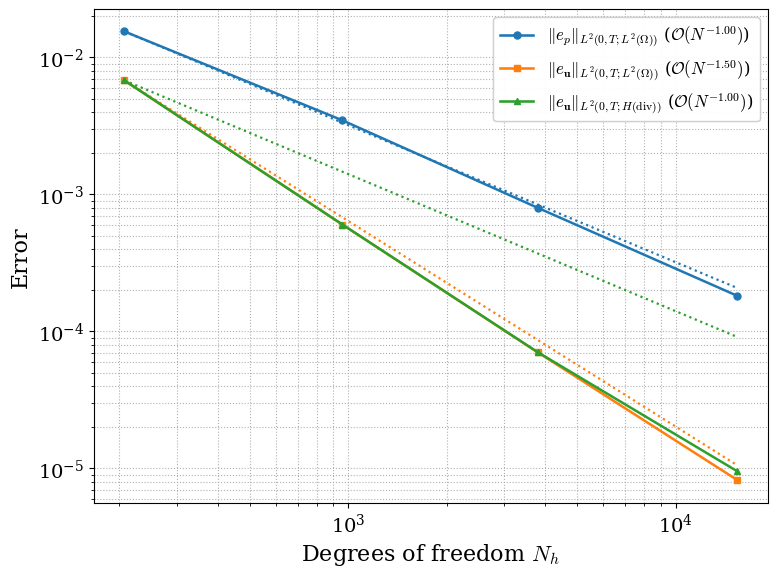

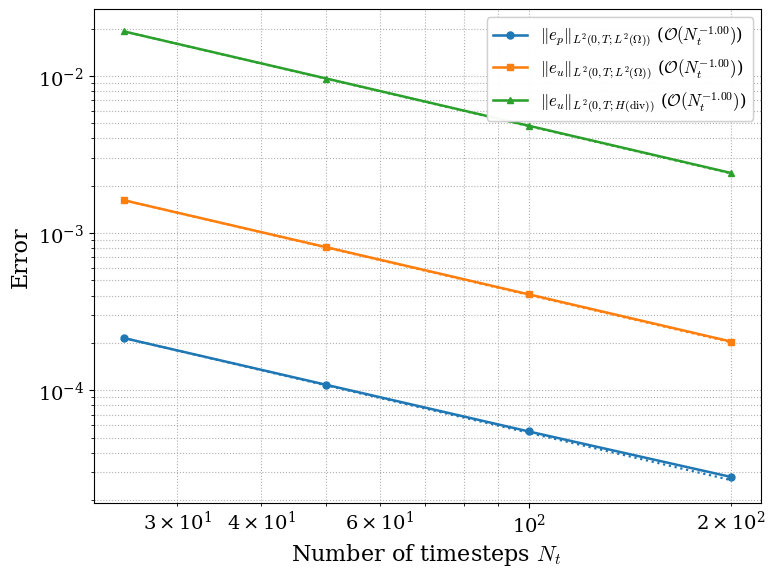

In [19]:
# Plot all 4 spatial errors for max-in-time
# latex_space = print_space_table(space_data, error_key_prefix="max", latex=True, label="tab:space_max")
# latex_time = print_time_table(time_data, error_key_prefix="max", latex=True, label="tab:time_max")

plot_space_convergence(
    data=space_data,
    dof_key="Ntot",
    error_type="l2t",
    expected_rates={
        "p": 1.0,
        "u": 1.5,
        "u_hdiv": 1.0,
    },
    savepath="plots/space_l2time_errors.pdf",
)

plot_time_convergence(
    data=time_data,
    error_type="l2t",
    expected_rates={
        "p": 1.0,
        "u": 1.0,
        "u_hdiv": 1.0,
    },
    savepath="plots/time_l2time_errors.pdf",
)

plt.show()

In [5]:
# ------------------------------------------------------------
# Space-time snapshots: pressure and velocity with mesh overlay
# Rows: FOM + mesh sizes h, Columns: times t
# ------------------------------------------------------------
import matplotlib.tri as mtri


def solve_vertex_snapshots(maxh=0.05, times=(0.1, 0.5, 0.9), order=2, Sstor=1.0, dt=1e-3, T=1.0):
    """Solve transient Darcy and collect nodal snapshots of p_h and |u_h| at selected times."""
    mesh = Mesh(unit_square.GenerateMesh(maxh=maxh))

    V = HDiv(mesh, order=order)
    Q = L2(mesh, order=order - 1)
    Y = FESpace([V, Q])

    (u, p) = Y.TrialFunction()
    (v, q) = Y.TestFunction()
    n = specialcf.normal(mesh.dim)

    S_cf = CoefficientFunction(Sstor)

    p_old = GridFunction(Q)
    p_old.Set(p_exact(0.0))

    gfu = GridFunction(Y)
    uh, ph = gfu.components

    a = BilinearForm(Y)
    a += (InnerProduct(u, v) - p * div(v) + q * div(u) + (S_cf / dt) * p * q) * dx
    a.Assemble()

    inv = a.mat.Inverse(Y.FreeDofs(), inverse="pardiso")

    pts = np.array([[v.point[0], v.point[1]] for v in mesh.vertices], dtype=float)
    xv, yv = pts[:, 0], pts[:, 1]

    tris = []
    for el in mesh.Elements(VOL):
        vids = [v.nr for v in el.vertices]
        if len(vids) == 3:
            tris.append(vids)
    tris = np.array(tris, dtype=int)

    triang = mtri.Triangulation(xv, yv, tris)

    target_times = np.array(times, dtype=float)
    Nt = int(round(T / dt))
    snapshots = {float(t): None for t in target_times}

    for nstep in range(1, Nt + 1):
        t = nstep * dt

        L = LinearForm(Y)
        L += (f_exact(t, Sstor) * q + (S_cf / dt) * p_old * q) * dx
        L += (-p_exact(t)) * InnerProduct(v.Trace(), n) * ds
        L.Assemble()

        gfu.vec.data = inv * L.vec
        p_old.vec.data = ph.vec

        for ttar in target_times:
            if snapshots[float(ttar)] is None and abs(t - ttar) <= 0.5 * dt:
                pvals = np.array([ph(mesh(xi, yi)) for xi, yi in pts], dtype=float)
                uvals = np.array([uh(mesh(xi, yi)) for xi, yi in pts], dtype=float)
                umag = np.sqrt(uvals[:, 0] ** 2 + uvals[:, 1] ** 2)
                snapshots[float(ttar)] = {"p": pvals, "u_mag": umag, "u": uvals}

    for ttar in target_times:
        if snapshots[float(ttar)] is None:
            pvals = np.array([ph(mesh(xi, yi)) for xi, yi in pts], dtype=float)
            uvals = np.array([uh(mesh(xi, yi)) for xi, yi in pts], dtype=float)
            umag = np.sqrt(uvals[:, 0] ** 2 + uvals[:, 1] ** 2)
            snapshots[float(ttar)] = {"p": pvals, "u_mag": umag, "u": uvals}

    return {"mesh": mesh, "pts": pts, "triang": triang, "snapshots": snapshots}


def build_space_time_data(hs, times, order=2, dt=1e-3, T=1.0, Sstor=1.0, include_fom=True, fom_h=0.02):
    data = {}

    if include_fom:
        data["FOM"] = solve_vertex_snapshots(
            maxh=float(fom_h),
            times=times,
            order=order,
            dt=dt,
            T=T,
            Sstor=Sstor,
        )

    for h in hs:
        data[float(h)] = solve_vertex_snapshots(
            maxh=float(h),
            times=times,
            order=order,
            dt=dt,
            T=T,
            Sstor=Sstor,
        )

    return data


def plot_space_time_field_grid(data_by_row, hs, times, field_key="p", cmap="viridis", savepath=None, quiver_n=11, quiver_color="white", quiver_scale_factor=8.0):
    """field_key: "p" or "u_mag". Creates rows=(Exact + hs), cols=times, shared axes + one colorbar."""
    from matplotlib import colors as mcolors

    hs = [float(h) for h in hs]
    times = [float(t) for t in times]

    row_keys = ["FOM"] + hs if "FOM" in data_by_row else hs

    def exact_uvec(mesh, pts, t):
        cf = u_exact(t)
        return np.array([cf(mesh(xi, yi)) for xi, yi in pts], dtype=float)

    def exact_vals(mesh, pts, t, fk):
        if fk == "p":
            cf = p_exact(t)
            return np.array([cf(mesh(xi, yi)) for xi, yi in pts], dtype=float)
        uvals = exact_uvec(mesh, pts, t)
        return np.sqrt(uvals[:, 0] ** 2 + uvals[:, 1] ** 2)

    all_vals = []
    for rk in row_keys:
        mesh = data_by_row[rk]["mesh"]
        pts = data_by_row[rk]["pts"]
        for t in times:
            if rk == "FOM":
                vals = exact_vals(mesh, pts, t, field_key)
            else:
                vals = data_by_row[rk]["snapshots"][t][field_key]
            all_vals.append(vals)
    all_concat = np.concatenate(all_vals)
    vmin = float(np.min(all_concat))
    vmax = float(np.max(all_concat))

    qx = np.linspace(0.08, 0.92, int(quiver_n))
    qy = np.linspace(0.08, 0.92, int(quiver_n))
    Xq, Yq = np.meshgrid(qx, qy)

    umax = 1e-14
    if field_key == "u_mag":
        for rk2 in row_keys:
            mesh2 = data_by_row[rk2]["mesh"]
            pts2 = data_by_row[rk2]["pts"]
            for t2 in times:
                if rk2 == "FOM":
                    uv2 = exact_uvec(mesh2, pts2, t2)
                else:
                    uv2 = data_by_row[rk2]["snapshots"][t2]["u"]
                spd2 = np.sqrt(uv2[:, 0] ** 2 + uv2[:, 1] ** 2)
                umax = max(umax, float(np.max(spd2)))

    nrows, ncols = len(row_keys), len(times)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(2.55 * ncols + 0.70, 2.30 * nrows),
        sharex=True,
        sharey=True,
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = np.array([[ax] for ax in axes])

    fig.subplots_adjust(left=0.08, right=0.86, bottom=0.04, top=0.94, wspace=0.03, hspace=0.06)

    mappable = None
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i, rk in enumerate(row_keys):
        triang = data_by_row[rk]["triang"]
        mesh = data_by_row[rk]["mesh"]
        pts = data_by_row[rk]["pts"]

        for j, t in enumerate(times):
            ax = axes[i, j]
            uvec = None
            if rk == "FOM":
                vals = exact_vals(mesh, pts, t, field_key)
                if field_key == "u_mag":
                    uvec = exact_uvec(mesh, pts, t)
            else:
                vals = data_by_row[rk]["snapshots"][t][field_key]
                if field_key == "u_mag":
                    uvec = data_by_row[rk]["snapshots"][t]["u"]

            if field_key == "p":
                mappable = ax.tripcolor(triang, vals, shading="gouraud", cmap=cmap, vmin=vmin, vmax=vmax)

            if rk != "FOM":
                h = float(rk)
                edge_lw = max(0.05, 0.40 * (h ** 0.85))
                edge_alpha = 0.5
                ax.triplot(triang, color="k", linewidth=edge_lw, alpha=edge_alpha)

            if field_key == "u_mag" and (uvec is not None) and int(quiver_n) > 0:
                iu = mtri.LinearTriInterpolator(triang, uvec[:, 0])
                iv = mtri.LinearTriInterpolator(triang, uvec[:, 1])
                Uq = np.ma.asarray(iu(Xq, Yq))
                Vq = np.ma.asarray(iv(Xq, Yq))
                Cq = np.ma.sqrt(Uq ** 2 + Vq ** 2)

                q = ax.quiver(
                    Xq,
                    Yq,
                    Uq,
                    Vq,
                    Cq,
                    cmap=cmap,
                    norm=norm,
                    angles="xy",
                    scale_units="xy",
                    scale=float(quiver_scale_factor) * float(umax),
                    width=0.0022*2,
                    alpha=1.0,
                )
                mappable = q

            if j == 0:
                row_label = "Exact" if rk == "FOM" else f"$h_{{\\max}} = {float(rk):g}$"
                ax.set_ylabel(row_label, rotation=90, labelpad=18)
            if i == 0:
                ax.set_title(f"t = {t:g}")

            ax.set_aspect("equal")
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(0.0, 1.0)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel("")

    if mappable is None:
        mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        mappable.set_array([])

    cax = fig.add_axes([0.875, 0.12, 0.020, 0.76])
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label(r"$p$" if field_key == "p" else r"$|\mathbf{u}|$")

    title = "Pressure snapshots (Exact + mesh levels)" if field_key == "p" else "Velocity magnitude snapshots (Exact + mesh levels)"
    # fig.suptitle(title)

    if savepath is not None:
        folder = os.path.dirname(savepath)
        if folder:
            os.makedirs(folder, exist_ok=True)
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, axes


# ---- configure and run snapshot plots ----
hs_snap = [0.32, 0.16, 0.08,0.04]
times_snap = [0.1, 0.5, 1.0]

# dt for visualization snapshots
dt_snap = 1e-3

# High-resolution reference row shown at top
fom_h = 0.02

os.makedirs("plots", exist_ok=True)




In [6]:
space_time_data = build_space_time_data(
    hs=hs_snap,
    times=times_snap,
    order=2,
    dt=dt_snap,
    T=1.0,
    Sstor=1.0,
    include_fom=True,
    fom_h=fom_h,
)


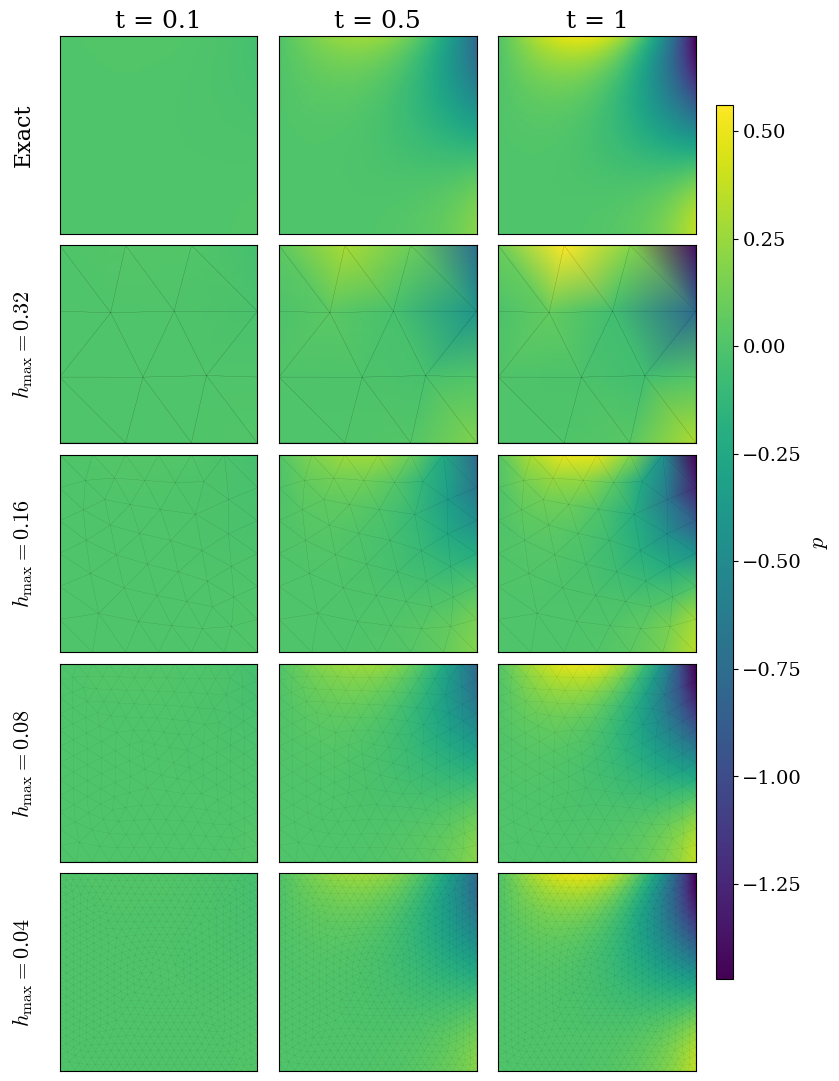

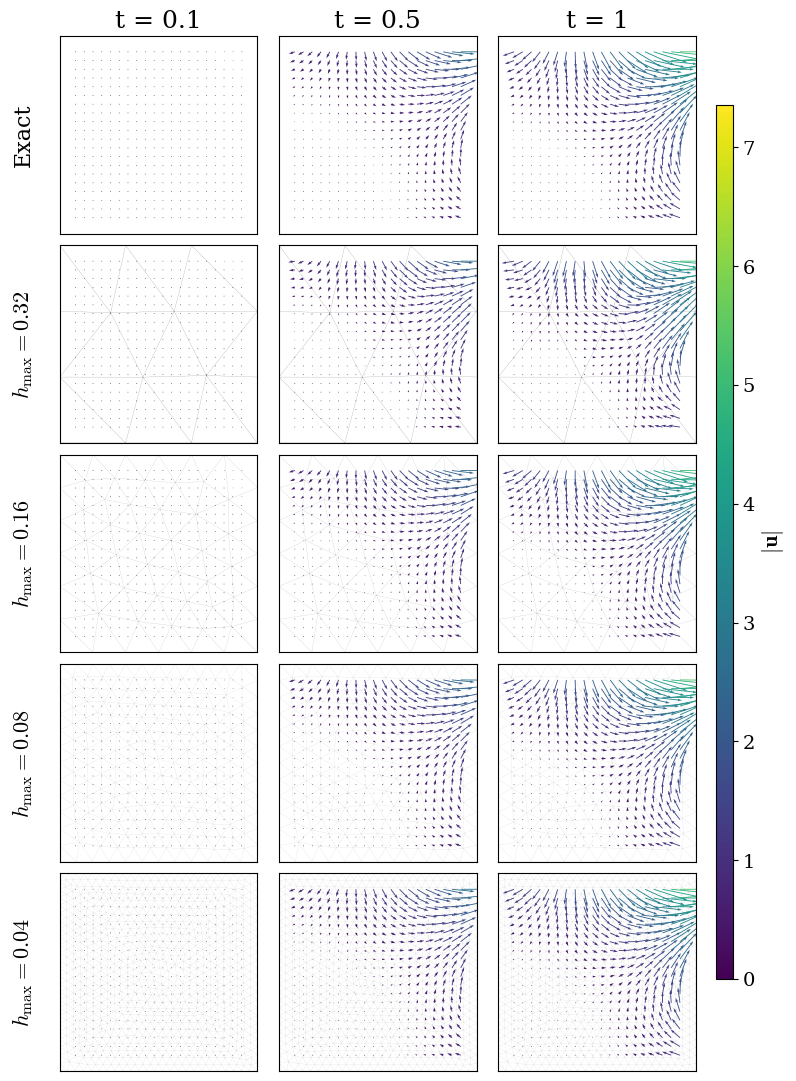

In [7]:
plot_space_time_field_grid(
    data_by_row=space_time_data,
    hs=hs_snap,
    times=times_snap,
    field_key="p",
    savepath="plots/pressure_space_time_mesh_overlay.pdf",
)

plot_space_time_field_grid(
    data_by_row=space_time_data,
    hs=hs_snap,
    times=times_snap,
    field_key="u_mag",
    quiver_n=20,
    quiver_scale_factor=3.0,
    savepath="plots/velocity_space_time_mesh_overlay.pdf",
)

plt.show()

